# set_32task — SET vs SET-static at 32 tasks, and the batch-size study

Non-stationary parallel MNIST at **32 tasks**, budget 101,632 weights (4x the
8-task budget, so per-task capacity is held constant), H=1536, `init_mode=epsilon`,
`prune_metric=utility`, `zeta=0.01` — the single winning configuration from
`set_analysis_v2`, carried forward rather than re-swept. The baseline is **SET
static** (`zeta=0`: the same network frozen at its ER-init topology), which beat
random-sparse at 8 tasks and so replaces it here.

Two studies, one Comet project (`set-32task-sweep`):

1. **`01_main`** — learning-rate sensitivity and learning curves for SET vs SET
   static at `batch_size=1`. 3 LR x 2 methods = 6 trials.
2. **`02_batch_size`** — `batch_size` in {1, 4, 16, 64} x LR {2^-6, 2^-5, 2^-4}
   x 2 methods = 24 trials, at a **fixed 512,000-sample budget**. Every step-based knob
   (`total_steps`, `log_freq`, `evolve_frequency`, `permute_period`,
   `utility_decay`) is derived from `batch_size` in `base_set.yaml`, so all cells
   see the identical data stream and drift schedule and differ *only* in how many
   optimizer updates they get (512k / 128k / 32k / 8k).

**The x-axis is samples, never steps.** A larger batch buys fewer updates over
the same data, which is the whole question — plotting against steps would hide
it. Every run logs exactly 500 points 1024 samples apart, so the sample axis is
directly comparable across batch sizes (see `_attach_sample_axis`).

Metric is the sweep objective `asymptotic_loss`, summed over the 32 tasks;
divide by `N_TASKS` for per-task loss. 5 seeds vmapped per trial.

**NaN handling.** Each cell is one vmapped-5-seed trial, so its asymptotic
summary is read directly. Diverged trials are set to NaN and *kept* (never
silently dropped), so a missing point is a visible gap rather than a hole in the
line that reads as "not run".

In [32]:
# # Run once to fetch from Comet. Comment out after first run.
# from phd.research_utils.scripts.comet_download import run as _comet_download
# _comet_download('set-32task-sweep', output_dir='data',
#                 include_running=True, include_crashed=True, discovery_samples=10_000)

In [33]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from phd.research_utils.analysis.analysis_utils import (
    set_matplotlib_style, get_color_palette, save_fig_versions, set_fig_labels,
)

set_matplotlib_style('2-row')
%matplotlib inline

PROJECT  = 'set-32task-sweep'
DATA_DIR = Path('data')
N_TASKS  = 32
METRIC     = 'asymptotic_loss'        # non-stationary: no held-out split
ACC_METRIC = 'asymptotic_accuracy'
METRIC_LABEL     = 'Asymptotic loss'
ACC_METRIC_LABEL = 'Asymptotic accuracy'

SWEEPS = {
    'set':        'set32_main_set',
    'set_static': 'set32_main_set_static',
    # _v2_: an earlier 4-LR version of the batch grid ran briefly before being
    # cancelled, and its partial trials are still in the project under the old
    # `set32_batch_*` names. Selecting on the v2 names excludes them outright.
    'batch_set':        'set32_batch_v2_set',
    'batch_set_static': 'set32_batch_v2_set_static',
}

METHOD_PALETTE = get_color_palette(classes=['SET', 'SET static (ζ=0)'])


def save_fig(name):
    save_fig_versions(name, dir='figures/pdf/', type='pdf')
    save_fig_versions(name, dir='figures/png/', type='png')

In [34]:
cfg_all = pd.read_csv(DATA_DIR / f'{PROJECT}_params.csv', index_col=0)
run_all = pd.read_csv(DATA_DIR / f'{PROJECT}_metrics.csv', index_col=0)

# optimizer.learning_rate (dotted) is the raw CLI override string
# ('${eval:2**-6}'); the pipe form is the resolved float. Use the pipe form.
cfg_all['learning_rate'] = pd.to_numeric(cfg_all['optimizer|learning_rate'], errors='coerce')

# Pipe-form columns are the *resolved* config, which is what we want for
# everything base_set.yaml derives from batch_size.
for c in ['train|batch_size', 'train|log_freq', 'train|total_steps',
          'set|zeta', 'set|evolve_frequency', 'set|utility_decay',
          'task|permute_period', 'task|n_tasks', 'target_hidden_units']:
    if c in cfg_all.columns:
        cfg_all[c] = pd.to_numeric(cfg_all[c], errors='coerce')

cfg_all['batch_size'] = cfg_all['train|batch_size'].astype('Int64')

print(f'{len(cfg_all)} trials, {len(run_all)} metric rows')
print(cfg_all['sweep_name'].value_counts())
print()
# Confirm the sample-timeline derivation actually landed on every trial: the
# samples-per-log period must be 1024 everywhere, which is what makes the
# sample axis comparable across batch sizes.
per_log = cfg_all['train|log_freq'] * cfg_all['train|batch_size']
print('samples per log period:', sorted(per_log.dropna().unique()))
print(cfg_all.groupby('batch_size')[
    ['train|total_steps', 'train|log_freq', 'set|evolve_frequency',
     'task|permute_period', 'set|utility_decay']].first().to_string())

85 trials, 37172 metric rows
sweep_name
set32_batch_v2_set           54
set32_batch_v2_set_static    25
set32_main_set                3
set32_main_set_static         3
Name: count, dtype: int64

samples per log period: [1024]
            train|total_steps  train|log_freq  set|evolve_frequency  task|permute_period  set|utility_decay
batch_size                                                                                                 
1                      512000            1024                   512                   64           0.998000
4                      128000             256                   128                   16           0.992024
16                      32000              64                    32                    4           0.968476
64                       8000              16                     8                    1           0.879741


In [35]:
SAMPLES_PER_LOG = 1024   # invariant across batch sizes, asserted below


def _attach_sample_axis(run, cfg):
    """Add a `samples` column: the x-axis for every plot in this notebook.

    comet_download's metrics CSV has no explicit step column; rows are
    pre-sorted per run by Comet's step index, so log-period k is row k. Each
    period covers `log_freq * batch_size` samples, and base_set.yaml derives
    `log_freq = 1024 // batch_size`, making that product 1024 for every run.
    Reconstructing in *samples* rather than steps is what puts a 512k-step B=1
    run and an 8k-step B=64 run on the same axis.
    """
    per_log = (cfg.set_index('run_id')['train|log_freq']
               * cfg.set_index('run_id')['train|batch_size'])
    run = run.reset_index(drop=True).copy()
    k = run.groupby('run_id').cumcount() + 1
    run['samples'] = k * run['run_id'].map(per_log)
    run['steps'] = run['samples'] / run['run_id'].map(
        cfg.set_index('run_id')['train|batch_size'])
    bad = per_log.dropna().loc[lambda s: s != SAMPLES_PER_LOG]
    assert bad.empty, (
        f'{len(bad)} run(s) have log_freq * batch_size != {SAMPLES_PER_LOG}, so '
        f'their sample axis is not comparable: {bad.unique()}'
    )
    return run


def _last(s):
    """Last non-NaN value of a series (the asymptotic summary is logged once)."""
    s = s.dropna()
    return s.iloc[-1] if len(s) else np.nan


def load_sweep(sweep_name, cell_cols):
    """Slice cfg+run to one sweep, dedupe Comet retries per experimental cell,
    and attach the per-run asymptotic `_metric` (NaN if the trial diverged).

    Each cell is a single vmapped-5-seed trial. Retries (a cell logged more than
    once after a timeout/crash) are deduped by keeping the most-complete trial
    (most metric rows). Diverged trials keep their row but get `_metric = NaN`,
    so they are never silently omitted.
    """
    cfg = cfg_all[cfg_all['sweep_name'] == sweep_name].copy()
    run = run_all[run_all['run_id'].isin(cfg['run_id'])].copy()
    if len(cfg) == 0:
        cfg['_metric'] = pd.Series(dtype=float)
        return cfg, run

    def _summary(col, name):
        """Per-run last value of a summary column, or all-NaN if the column is
        absent. It is missing entirely when no run in the download has finished
        yet (comet_download with include_running=True), which should render as
        gaps rather than a KeyError."""
        if col not in run.columns:
            return pd.Series(dtype=float, name=name)
        return run.groupby('run_id')[col].apply(_last).rename(name)

    n_rows = run.groupby('run_id').size().rename('_n_rows')
    div = _summary('diverged', '_div')
    asym = _summary(METRIC, '_metric')
    asym_acc = _summary(ACC_METRIC, '_acc')

    cfg = (cfg.merge(n_rows,   left_on='run_id', right_index=True, how='left')
              .merge(div,      left_on='run_id', right_index=True, how='left')
              .merge(asym,     left_on='run_id', right_index=True, how='left')
              .merge(asym_acc, left_on='run_id', right_index=True, how='left'))
    cfg['_n_rows'] = cfg['_n_rows'].fillna(0).astype(int)
    cfg['_div'] = cfg['_div'].fillna(0)
    cfg.loc[cfg['_div'] > 0.5, ['_metric', '_acc']] = np.nan
    cfg['_metric'] = cfg['_metric'] / N_TASKS          # per-task loss
    # `_acc` is already a mean over tasks, so it is NOT divided by N_TASKS.

    cfg = cfg.sort_values('_n_rows', ascending=False).drop_duplicates(cell_cols, keep='first')
    run = _attach_sample_axis(run[run['run_id'].isin(cfg['run_id'])], cfg)
    return cfg, run


def best_cfg_row(cfg):
    """Row of the best (lowest `_metric`) configuration; diverged excluded."""
    valid = cfg.dropna(subset=['_metric'])
    return None if len(valid) == 0 else valid.loc[valid['_metric'].idxmin()]


def lr_label(lr):
    return f'$2^{{{int(np.log2(lr))}}}$'

## 1. Main study — learning-rate sensitivity

`batch_size=1`, everything else fixed at the 8-task winner. The 8-task optimum
sat at the *top* of its LR range (2^-6 of {2^-10..2^-6}), so this grid is shifted
up an octave to {2^-7, 2^-6, 2^-5}. **Result: 2^-6 won for both arms** and is
interior, so no extension was needed and the batch study is anchored on it.

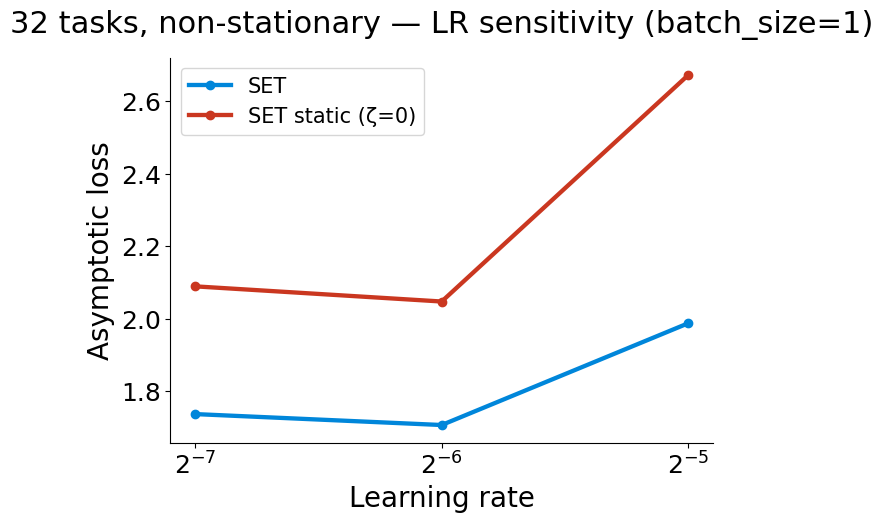

--- SET: 3 cells, 0 diverged
 learning_rate  _metric  log2_lr
        0.0078   1.7361     -7.0
        0.0156   1.7059     -6.0
        0.0312   1.9871     -5.0
--- SET static: 3 cells, 0 diverged
 learning_rate  _metric  log2_lr
        0.0078   2.0890     -7.0
        0.0156   2.0471     -6.0
        0.0312   2.6728     -5.0


In [36]:
def plot_lr_sensitivity(curves, title, save_name, ylabel=METRIC_LABEL):
    """One line per method: asymptotic loss vs LR. A gap = that cell diverged."""
    fig, ax = plt.subplots()
    for label, cfg in curves.items():
        agg = (cfg.groupby('learning_rate')['_metric'].min().reset_index()
               if len(cfg) else pd.DataFrame(columns=['learning_rate', '_metric']))
        ax.plot(np.log2(agg['learning_rate']), agg['_metric'], marker='o',
                label=label, color=METHOD_PALETTE.get(label))
    ax.set_xlabel('Learning rate'); ax.set_ylabel(ylabel); ax.set_title(title)
    ticks = sorted({int(np.log2(v)) for cfg in curves.values()
                    for v in cfg['learning_rate'].dropna().unique()})
    ax.set_xticks(ticks); ax.set_xticklabels([f'$2^{{{t}}}$' for t in ticks])
    ax.legend()
    save_fig(save_name)
    plt.show()


set_cfg,  set_run  = load_sweep(SWEEPS['set'],        ['learning_rate'])
stat_cfg, stat_run = load_sweep(SWEEPS['set_static'], ['learning_rate'])

plot_lr_sensitivity(
    {'SET': set_cfg, 'SET static (ζ=0)': stat_cfg},
    title='32 tasks, non-stationary — LR sensitivity (batch_size=1)',
    save_name='main_lr_sensitivity',
)

for name, cfg in [('SET', set_cfg), ('SET static', stat_cfg)]:
    print(f'--- {name}: {len(cfg)} cells, {cfg["_metric"].isna().sum()} diverged')
    print(cfg[['learning_rate', '_metric']].sort_values('learning_rate')
          .assign(log2_lr=lambda d: np.log2(d['learning_rate'])).round(4).to_string(index=False))

## 2. Main study — learning curves of the best configuration

Best = lowest asymptotic per-task loss. Shaded band = across-seed std.
x-axis is samples (= steps here, since `batch_size=1`).

SET                best lr=2^-6 -> 1.7059 per-task loss
SET static (ζ=0)   best lr=2^-6 -> 2.0471 per-task loss


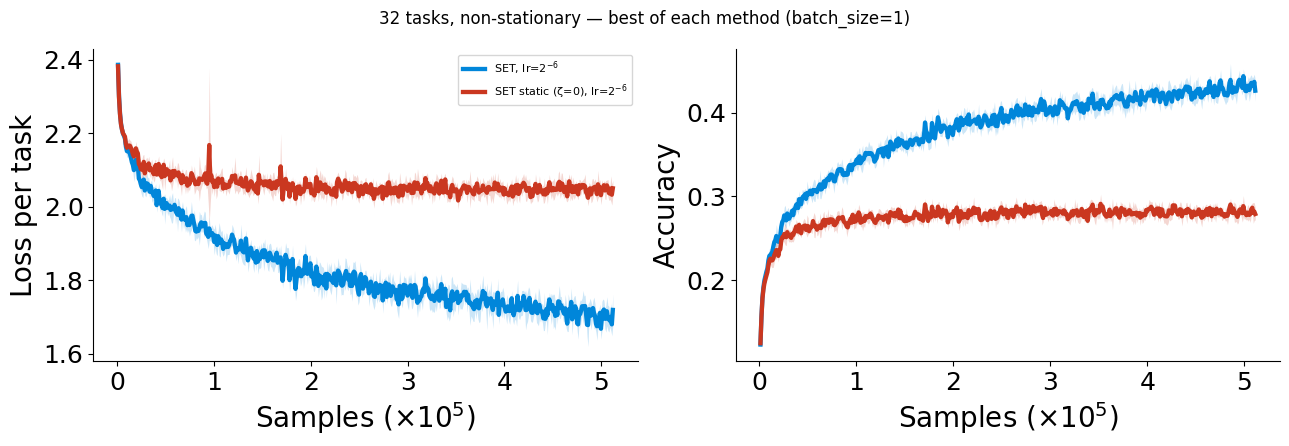

In [37]:
def plot_curves(entries, title, save_name, x='samples', xlabel='Samples'):
    """entries: list of (label, color, cfg_row, run). Two panels: loss, accuracy."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for ax, (y_col, std_col, scale, ylab) in zip(
        axes, [('loss', 'loss_std', N_TASKS, 'Loss per task'),
               ('accuracy', 'accuracy_std', 1.0, 'Accuracy')]):
        for label, color, row, run in entries:
            sub = run[run['run_id'] == row['run_id']].sort_values(x)
            xs, ys = sub[x].values, sub[y_col].values / scale
            ax.plot(xs, ys, label=label, color=color)
            if std_col in sub.columns:
                s = sub[std_col].values / scale
                ax.fill_between(xs, ys - s, ys + s, alpha=0.2, color=color, linewidth=0)
        # Samples run to 512,000, so plain ticks read as 0/100000/200000/... and
        # collide. xsci moves the common factor into the axis label ("Samples
        # (x10^5)") and leaves the ticks as single digits.
        set_fig_labels(xlabel, ylab, xsci=True, ax=ax)
    axes[0].legend(fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    # save_fig_versions toggles the legend on plt.gca(), which tight_layout
    # leaves pointing at the right-hand panel -- point it back at the legend.
    plt.sca(axes[0])
    save_fig(save_name)
    plt.show()


entries = []
for label, cfg, run in [('SET', set_cfg, set_run),
                        ('SET static (ζ=0)', stat_cfg, stat_run)]:
    row = best_cfg_row(cfg)
    if row is not None:
        entries.append((f'{label}, lr={lr_label(row["learning_rate"])}',
                        METHOD_PALETTE[label], row, run))
        print(f'{label:18s} best lr=2^{int(np.log2(row["learning_rate"]))} '
              f'-> {row["_metric"]:.4f} per-task loss')

plot_curves(entries, '32 tasks, non-stationary — best of each method (batch_size=1)',
            'main_learning_curves')

## 3. Batch-size study — does the best step-size move with the batch?

One line per batch size. All four see the same 512,000 samples with the same
drift schedule, so a difference between lines is a difference in *how the
updates are spent*, not in the problem. The LR at each line's minimum is the
one used for the learning curves below.

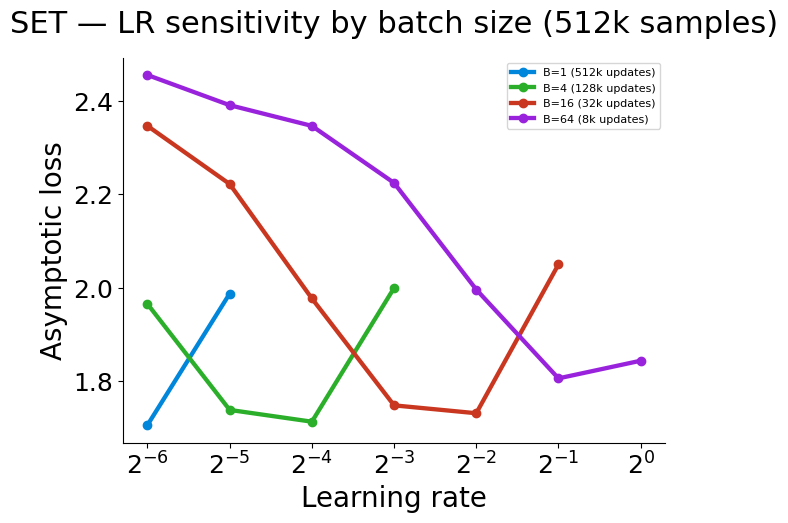

--- SET: 28 cells, 9 diverged
learning_rate  0.015625  0.031250  0.062500  0.125000  0.250000  0.500000  1.000000
batch_size                                                                         
1                1.7059    1.9871       NaN       NaN       NaN       NaN       NaN
4                1.9649    1.7382    1.7130    1.9992       NaN       NaN       NaN
16               2.3461    2.2217    1.9768    1.7480    1.7311    2.0496       NaN
64               2.4550    2.3905    2.3462    2.2241    1.9959    1.8057    1.8435
best LR per batch size:
 batch_size  learning_rate  _metric  log2_lr
          1         0.0156   1.7059     -6.0
          4         0.0625   1.7130     -4.0
         16         0.2500   1.7311     -2.0
         64         0.5000   1.8057     -1.0


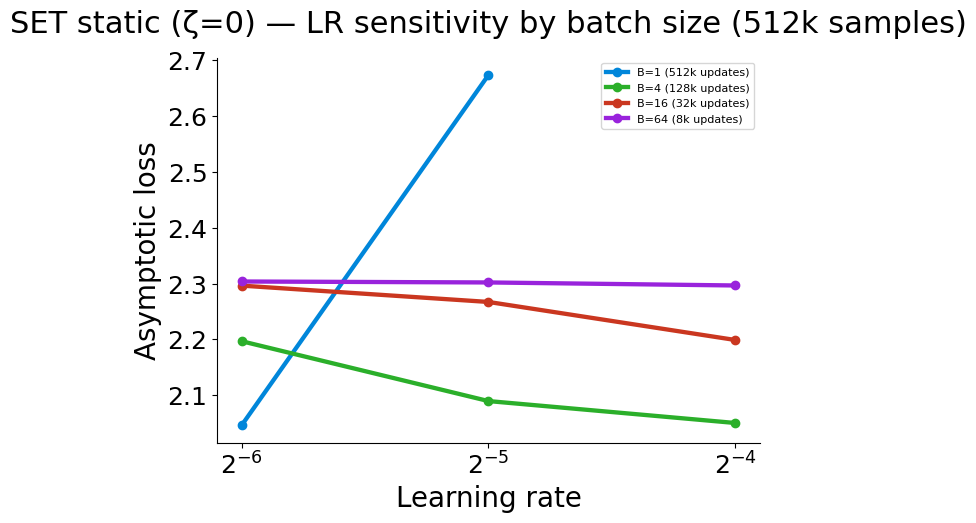

--- SET static (ζ=0): 12 cells, 1 diverged
learning_rate  0.015625  0.031250  0.062500
batch_size                                 
1                2.0471    2.6728       NaN
4                2.1968    2.0899    2.0508
16               2.2963    2.2671    2.1992
64               2.3037    2.3020    2.2966
best LR per batch size:
 batch_size  learning_rate  _metric  log2_lr
          1         0.0156   2.0471     -6.0
          4         0.0625   2.0508     -4.0
         16         0.0625   2.1992     -4.0
         64         0.0625   2.2966     -4.0


In [38]:
BATCH_CELL = ['learning_rate', 'batch_size']
bset_cfg,  bset_run  = load_sweep(SWEEPS['batch_set'],        BATCH_CELL)
bstat_cfg, bstat_run = load_sweep(SWEEPS['batch_set_static'], BATCH_CELL)

BATCHES = sorted(pd.concat([bset_cfg['batch_size'], bstat_cfg['batch_size']]).dropna().unique())
BATCH_PALETTE = get_color_palette(classes=[str(b) for b in BATCHES])

for name, cfg in [('SET', bset_cfg), ('SET static (ζ=0)', bstat_cfg)]:
    fig, ax = plt.subplots()
    for b in BATCHES:
        sub = cfg[cfg['batch_size'] == b]
        agg = sub.groupby('learning_rate')['_metric'].min().reset_index()
        ax.plot(np.log2(agg['learning_rate']), agg['_metric'], marker='o',
                label=f'B={b} ({512_000 // b // 1000}k updates)',
                color=BATCH_PALETTE[str(b)])
    ax.set_xlabel('Learning rate'); ax.set_ylabel(METRIC_LABEL)
    ax.set_title(f'{name} — LR sensitivity by batch size (512k samples)')
    ticks = sorted({int(np.log2(v)) for v in cfg['learning_rate'].dropna().unique()})
    ax.set_xticks(ticks); ax.set_xticklabels([f'$2^{{{t}}}$' for t in ticks])
    ax.legend(fontsize=8)
    save_fig(f'batch_lr_sensitivity_{"set" if name == "SET" else "set_static"}')
    plt.show()

    print(f'--- {name}: {len(cfg)} cells, {cfg["_metric"].isna().sum()} diverged')
    print(cfg.pivot_table(index='batch_size', columns='learning_rate',
                          values='_metric').round(4).to_string())
    best = cfg.dropna(subset=['_metric']).loc[
        lambda d: d.groupby('batch_size')['_metric'].idxmin()]
    print('best LR per batch size:')
    print(best[['batch_size', 'learning_rate', '_metric']]
          .assign(log2_lr=lambda d: np.log2(d['learning_rate']))
          .sort_values('batch_size').round(4).to_string(index=False))

## 4. Batch-size study — learning curves against samples

Each batch size at its own best LR. The x-axis is **samples**, so all curves
span the same 512,000 and the larger batches are simply making fewer, larger
steps along it. Both methods are shown: if large batches hurt SET specifically
(rather than SGD generally), the gap between the two panels will widen with B.

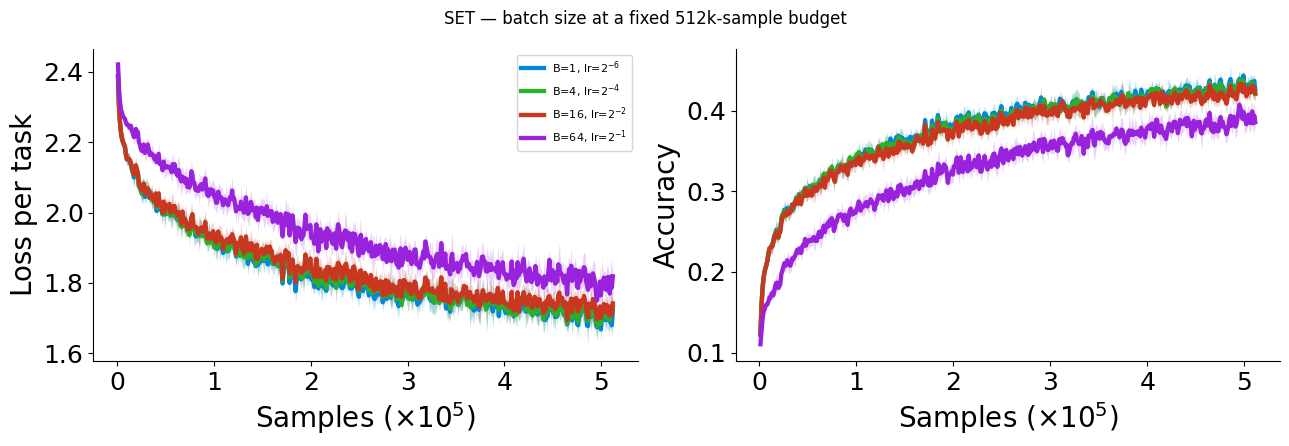

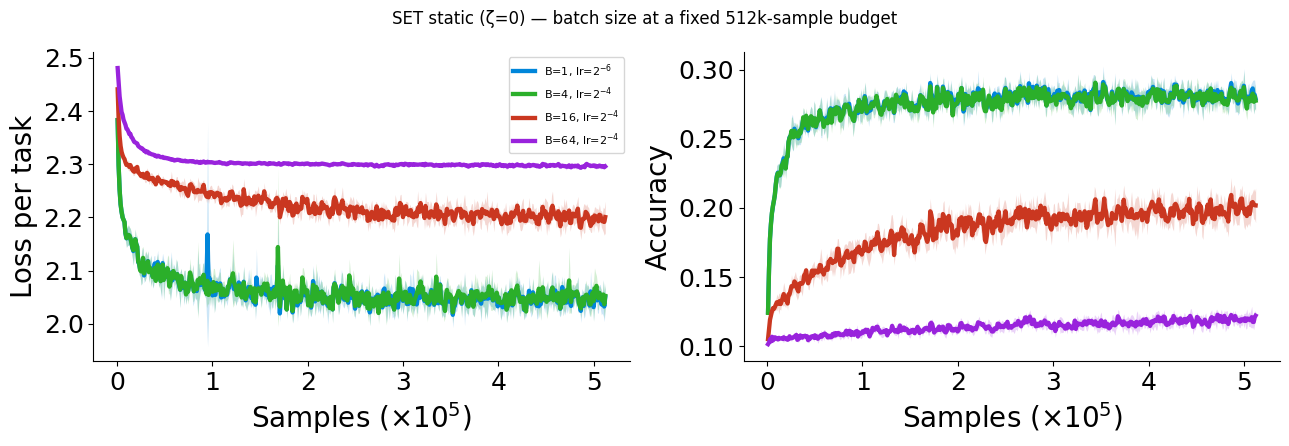

In [39]:
for name, cfg, run, tag in [('SET', bset_cfg, bset_run, 'set'),
                            ('SET static (ζ=0)', bstat_cfg, bstat_run, 'set_static')]:
    entries = []
    valid = cfg.dropna(subset=['_metric'])
    for b in BATCHES:
        sub = valid[valid['batch_size'] == b]
        if len(sub) == 0:
            continue
        row = sub.loc[sub['_metric'].idxmin()]
        entries.append((f'B={b}, lr={lr_label(row["learning_rate"])}',
                        BATCH_PALETTE[str(b)], row, run))
    plot_curves(entries, f'{name} — batch size at a fixed 512k-sample budget',
                f'batch_learning_curves_{tag}')

## 5. Batch-size sensitivity — batch size on the x-axis

The transpose of section 3: **batch size** on the x-axis with **learning rate**
as the hue, in loss and accuracy. Section 3 asks "where is the best LR for this
batch?"; this asks the headline question directly — **what does increasing the
batch cost you, at a fixed sample budget?**

Read the *lower envelope* across the LR lines: that is the best achievable result
at each batch size, and its slope is the real answer. An individual LR line
rising with B can just mean that LR has become too small for the reduced update
count, which is a statement about that LR rather than about batching.

Watch for edge-pinning: if the best line at B=16 or B=64 is the top of the LR
grid (2^-4), that cell's optimum lies outside the grid and its point is only an
upper bound on loss -- extend the grid before concluding that large batches hurt.

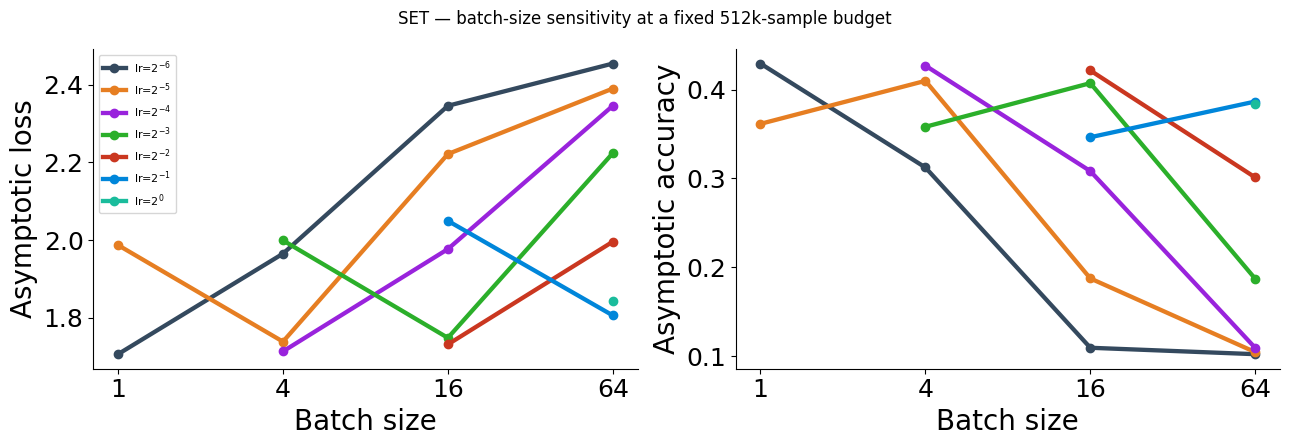

--- SET: best-over-LR envelope ---
 batch_size  learning_rate  _metric   _acc  _at_edge  log2_lr
          1         0.0156   1.7059 0.4292     False     -6.0
          4         0.0625   1.7130 0.4269     False     -4.0
         16         0.2500   1.7311 0.4214     False     -2.0
         64         0.5000   1.8057 0.3865     False     -1.0


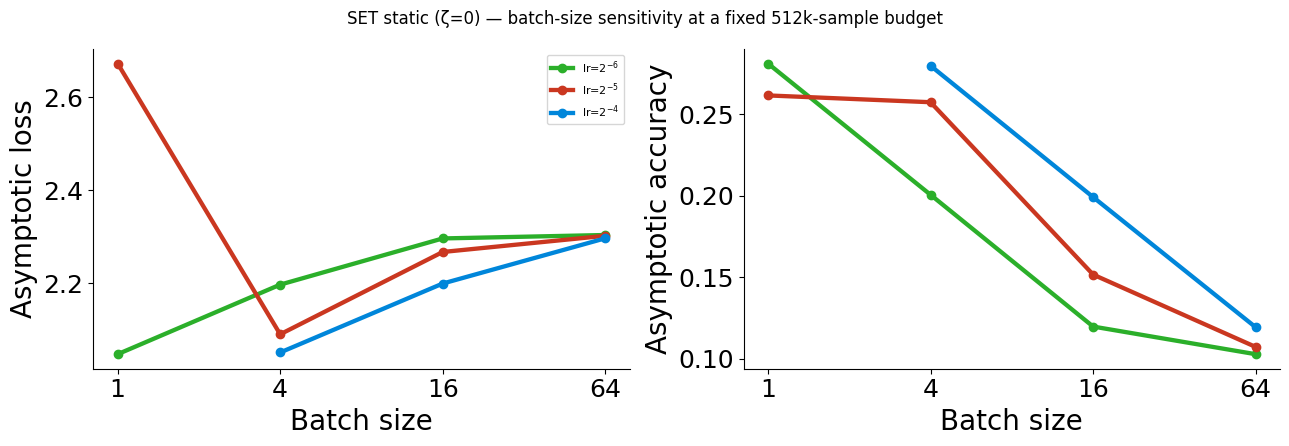

--- SET static (ζ=0): best-over-LR envelope ---
 batch_size  learning_rate  _metric   _acc  _at_edge  log2_lr
          1         0.0156   2.0471 0.2811     False     -6.0
          4         0.0625   2.0508 0.2797      True     -4.0
         16         0.0625   2.1992 0.1992      True     -4.0
         64         0.0625   2.2966 0.1194      True     -4.0


In [40]:
def best_per_batch(cfg):
    """One row per batch size: the cell with the lowest loss.

    Accuracy is taken from that same row rather than maximised independently, so
    both panels of a plot describe one configuration.

    `_at_edge` marks rows whose winning LR is the largest this arm has data for.
    The optimum may lie beyond it, so such a point is only an upper bound on
    loss. This matters here: the SET arm's grid was extended twice (to 2^-3,
    then to 2^0) precisely because the large batches kept wanting a bigger step,
    and the static arm has not been extended, so the two arms have different
    edges.
    """
    valid = cfg.dropna(subset=['_metric'])
    if len(valid) == 0:
        return valid.assign(_at_edge=False)
    env = (valid.loc[valid.groupby('batch_size')['_metric'].idxmin()]
                .sort_values('batch_size').copy())
    env['_at_edge'] = env['learning_rate'] >= valid['learning_rate'].max()
    return env


def plot_batch_sensitivity(cfg, name, tag):
    """Batch size on x, one line per LR, loss and accuracy panels."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    lrs = sorted(cfg['learning_rate'].dropna().unique())
    lr_palette = get_color_palette(classes=[lr_label(v) for v in lrs])

    for ax, (col, ylab, better) in zip(
        axes, [('_metric', METRIC_LABEL, 'lower is better'),
               ('_acc', ACC_METRIC_LABEL, 'higher is better')]):
        for lr in lrs:
            sub = (cfg[cfg['learning_rate'] == lr]
                   .sort_values('batch_size')
                   .drop_duplicates('batch_size'))
            # Diverged cells are NaN and stay NaN -> the line breaks at that
            # batch size instead of silently interpolating across it.
            ax.plot(np.log2(sub['batch_size'].astype(float)), sub[col],
                    marker='o', label=f'lr={lr_label(lr)}',
                    color=lr_palette[lr_label(lr)])
        ax.set_xticks([np.log2(b) for b in BATCHES])
        ax.set_xticklabels([str(int(b)) for b in BATCHES])
        ax.set_xlabel('Batch size')
        ax.set_ylabel(f'{ylab}')
    axes[0].legend(fontsize=8)
    fig.suptitle(f'{name} — batch-size sensitivity at a fixed 512k-sample budget')
    fig.tight_layout()
    plt.sca(axes[0])
    save_fig(f'batch_size_sensitivity_{tag}')
    plt.show()

    env = best_per_batch(cfg)
    print(f'--- {name}: best-over-LR envelope ---')
    print(env[['batch_size', 'learning_rate', '_metric', '_acc', '_at_edge']]
          .assign(log2_lr=lambda d: np.log2(d['learning_rate']))
          .round(4).to_string(index=False))


for name, cfg, tag in [('SET', bset_cfg, 'set'),
                       ('SET static (ζ=0)', bstat_cfg, 'set_static')]:
    plot_batch_sensitivity(cfg, name, tag)

## 6. Batch-size sensitivity — tuned envelope only

Section 5 with the LR lines collapsed to **one line**: at each batch size, the
learning rate that minimises loss. This is the plot that answers "what does a
larger batch cost, once each batch size is individually tuned?", without the
clutter of the learning rates that lost.

Accuracy is read off the *same* cell that minimised loss, not maximised
separately, so both panels describe a single configuration.

Each point is annotated with its winning LR, which is where the interesting
structure is: if that annotation climbs with batch size, larger batches are
buying back some of their lost update count with a bigger step.

A **hollow marker** means the winning LR is the largest in that arm's grid, so
the true optimum may lie beyond it and the point is only an upper bound on loss.
Worth watching, because the two arms have different edges — the SET grid was
extended twice (to 2^-3, then to 2^0) as the large batches kept wanting a bigger
step, while the static arm still stops at 2^-4.

/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:242: UserWarning: No legend found
  warnings.warn('No legend found')
/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:242: UserWarning: No legend found
  warnings.warn('No legend found')


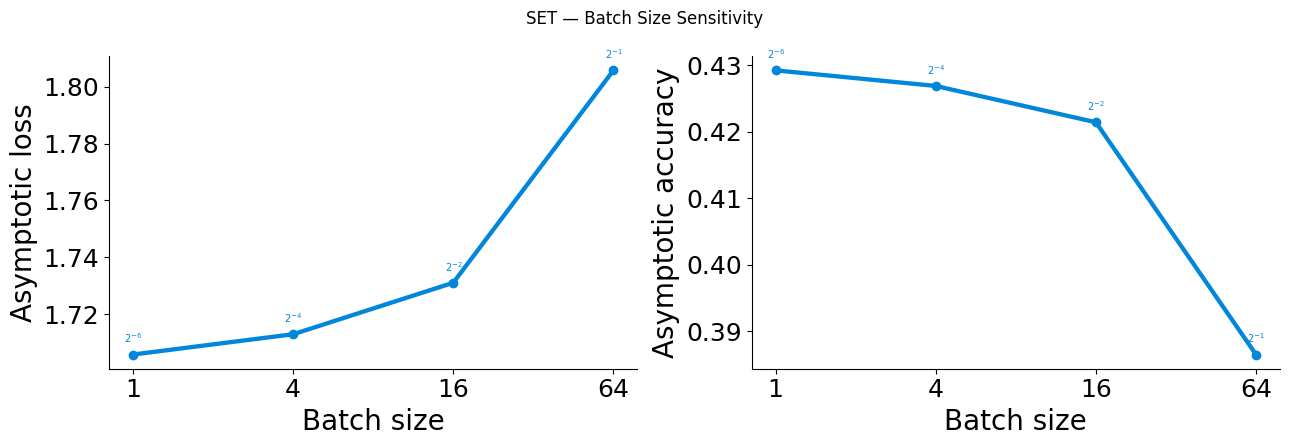

SET: per-task loss 1.7059 at B=1 -> 1.8057 at B=64 (+5.9%), accuracy 0.4292 -> 0.3865


/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:242: UserWarning: No legend found
  warnings.warn('No legend found')
/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:242: UserWarning: No legend found
  warnings.warn('No legend found')


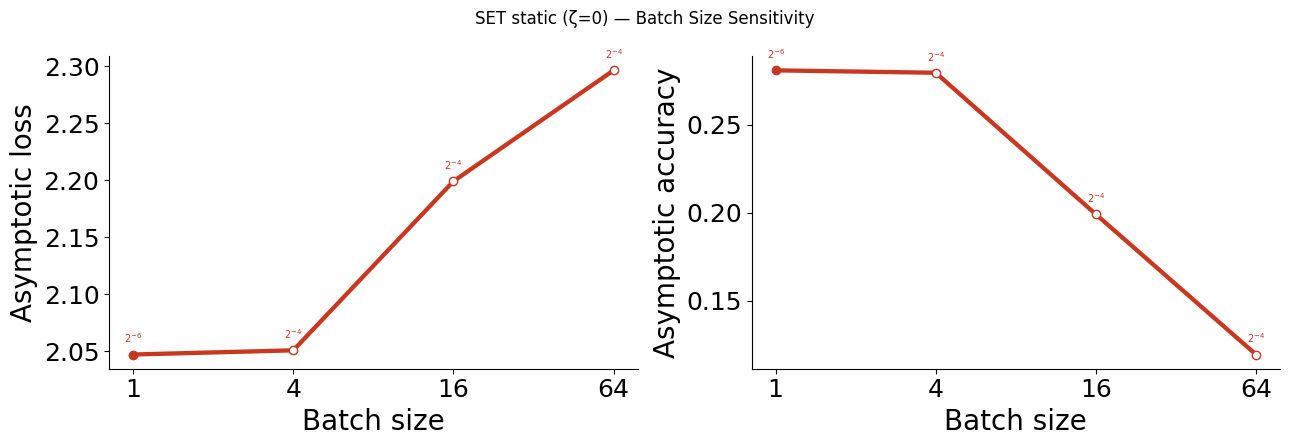

SET static (ζ=0): per-task loss 2.0471 at B=1 -> 2.2966 at B=64 (+12.2%), accuracy 0.2811 -> 0.1194
  ! batch size(s) [4, 16, 64] won at the top of the LR grid (2^-4) — their optima may lie beyond it, so the reported rise is an upper bound.


In [ ]:
def plot_batch_envelope(cfg, name, tag):
    """Section 5 collapsed to a single tuned line: at each batch size, the LR
    that minimises loss. Loss and accuracy panels, annotated with that LR."""
    env = best_per_batch(cfg)
    if len(env) == 0:
        print(f'{name}: no valid cells yet')
        return

    color = METHOD_PALETTE.get(name, METHOD_PALETTE['SET'])
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    x = np.log2(env['batch_size'].astype(float)).values

    for ax, (col, ylab, better) in zip(
        axes, [('_metric', METRIC_LABEL, 'lower is better'),
               ('_acc', ACC_METRIC_LABEL, 'higher is better')]):
        y = env[col].values
        ax.plot(x, y, color=color, zorder=2)
        # Hollow marker = the winning LR is the largest in this arm's grid, so
        # the optimum may lie beyond it and the point is only a bound.
        for edge, face in [(False, color), (True, 'white')]:
            m = (env['_at_edge'] == edge).values
            if m.any():
                ax.plot(
                    x[m], y[m], linestyle='none', marker='o', color=color,
                    markerfacecolor=face, markeredgecolor=color, zorder=3,
                )
        for xi, yi, lr in zip(x, y, env['learning_rate']):
            if np.isfinite(yi):
                ax.annotate(lr_label(lr), (xi, yi), textcoords='offset points',
                            xytext=(0, 8), ha='center', fontsize=7, color=color)
        ax.set_xticks([np.log2(b) for b in BATCHES])
        ax.set_xticklabels([str(int(b)) for b in BATCHES])
        ax.set_xlabel('Batch size')
        ax.set_ylabel(f'{ylab}')
    fig.suptitle(f'{name} — Batch Size Sensitivity')
    fig.tight_layout()
    plt.sca(axes[0])
    save_fig(f'batch_size_envelope_{tag}')
    plt.show()

    first, last = env.iloc[0], env.iloc[-1]
    print(f'{name}: per-task loss {first["_metric"]:.4f} at B={int(first["batch_size"])} '
          f'-> {last["_metric"]:.4f} at B={int(last["batch_size"])} '
          f'({(last["_metric"] / first["_metric"] - 1) * 100:+.1f}%), '
          f'accuracy {first["_acc"]:.4f} -> {last["_acc"]:.4f}')
    if env['_at_edge'].any():
        pinned = [int(b) for b in env.loc[env['_at_edge'], 'batch_size']]
        print(f'  ! batch size(s) {pinned} won at the top of the LR grid '
              f'(2^{int(np.log2(env["learning_rate"].max()))}) — their optima may lie '
              f'beyond it, so the reported rise is an upper bound.')


for name, cfg, tag in [('SET', bset_cfg, 'set'),
                       ('SET static (ζ=0)', bstat_cfg, 'set_static')]:d
    plot_batch_envelope(cfg, name, tag)